In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout

# 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv')

In [253]:
# 컬럼 확인
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [254]:
# 레이블 분포 확인
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [255]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [256]:
# 결측치 확인
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [257]:
# 결측치 제거
df = df.dropna()

In [258]:
# 입력(X), 정답(y) 분리
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [259]:
# numpy 변환
X = X.values
y = y.values

In [260]:
# train / test 분리
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**손실함수**

• Binary Crossentropy

이 손실 함수는 이진 분류 문제(binary classification)에 사용된다. 모델은 두 개의 클래스 중 하나를 예측해야 하며, 정답은 일반적으로 0 또는 1의 형태로 표현된다.
이 경우 출력층에는 시그모이드(sigmoid) 활성화 함수를 사용한다. 시그모이드는 입력값을 0과 1 사이의 값으로 변환하여 특정 클래스(보통 1)에 속할 확률을 출력한다.

• Categorical Crossentropy

이 손실 함수는 다중 클래스 분류 문제(multi-class classification)에 사용된다. 모델은 세 개 이상의 클래스 중 하나를 선택해야 하며, 정답은 일반적으로 원-핫 인코딩(one-hot encoding) 형태로 표현된다. 출력층에는 소프트맥스(softmax) 활성화 함수를 사용하며, 이 함수는 각 클래스에 대한 확률 분포를 생성하고 전체 합이 1이 되도록 정규화한다.

In [261]:
# 모델 정의
model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [262]:
# 학습
model_history = model.fit(
    x=X_train,
    y=y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6762 - loss: 0.6192 - val_accuracy: 0.6992 - val_loss: 0.5463
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7536 - loss: 0.5408 - val_accuracy: 0.7724 - val_loss: 0.4995
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7617 - loss: 0.5012 - val_accuracy: 0.7480 - val_loss: 0.4848
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7719 - loss: 0.4840 - val_accuracy: 0.7642 - val_loss: 0.4799
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7617 - loss: 0.4818 - val_accuracy: 0.7805 - val_loss: 0.4810
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7658 - loss: 0.4814 - val_accuracy: 0.7805 - val_loss: 0.4821
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7739 - loss: 0.4565 - val_accuracy: 0.7805 - val_loss: 0.4793
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7841 - loss: 0.4646 - val_accuracy: 0.7886 - val_loss

In [263]:
# 예측
y_pred = model.predict(X_test)

# 확률 -> 0/1 클래스 변환
y_pred_class = (y_pred > 0.5).astype(int).reshape(-1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


**loss 그래프**

모델의 예측값과 실제값 사이의 오차를 나타내는 지표

 학습 과정에서 모델이 얼마나 잘못 예측하고 있는지를 수치적으로 보여주며, 값이 낮을수록 모델의 성능이 좋은 상태

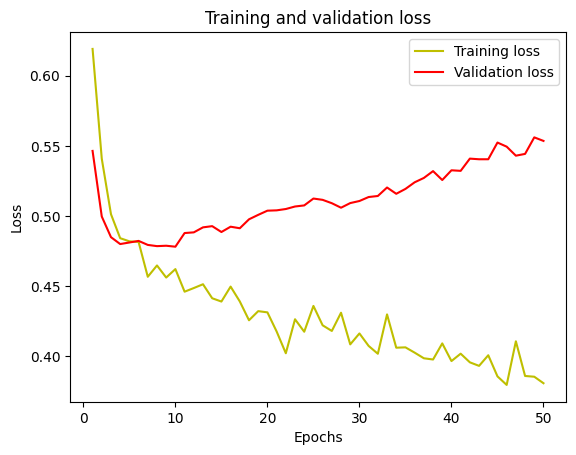

In [264]:
# loss 그래프
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**accuracy 그래프**

학습 과정에서 모델이 데이터를 얼마나 정확하게 분류하는지를 나타내는 지표

epoch에 따라 학습 데이터의 정확도와 검증 데이터의 정확도 변화를 확인할 수 있는 값


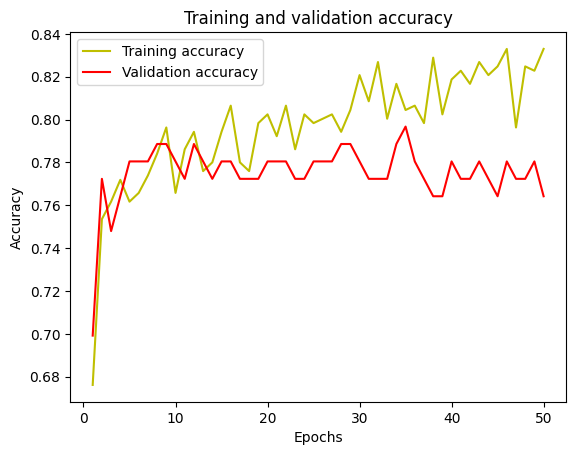

In [265]:
# accuracy 그래프
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**모델 평가**

**classification_report:**

실제값(y_test)과 예측값(y_pred_class)을 비교하여
정밀도(precision), 재현율(recall), F1-score를 계산
모델이 각 클래스를 얼마나 정확하게 분류하는지 수치적으로 확인

**confusion_matrix:**

실제 클래스와 예측 클래스를 행렬 형태로 출력
행: 실제값, 열: 예측값
어떤 클래스를 맞췄는지 / 어디서 틀렸는지 직관적으로 분석 가능

In [266]:
print(classification_report(y_test, y_pred_class))
print(confusion_matrix(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       107
           1       0.64      0.64      0.64        47

    accuracy                           0.78       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.78      0.78      0.78       154

[[90 17]
 [17 30]]
